# Cài đặt các Thư viện sử dụng

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from underthesea import word_tokenize
import os

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Cài đặt hiển thị dataFrame

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Đọc dữ liệu


- vn_news_223_tdlfr.csv là file chứa news cần xử lý
- vietnamese-stopwords.txt chứa các stop word cần xử lý

In [4]:

file = os.path.join("../../Data_Train", "Vietnamese.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

file_stopword = os.path.join("../../Data_Train", "vietnamese-stopwords-dash.txt")
with open(file_stopword, 'r', encoding='utf-8') as file:
    stopwords = file.read().split('\n')

In [43]:
model_vector = os.path.join("../../Model/Vietnamese", "vectorizer.joblib")
model_DTC = os.path.join("../../Model/Vietnamese", "DT_model.joblib")
model_NB = os.path.join("../../Model/Vietnamese", "NB_model.joblib")


# Khám phá dữ liệu

## Mẫu dữ liệu

In [6]:
data_df.sample(1)

,title,text,label
12410,Sản phẩm kinh hoàng của một nhà nước bạo lực,1 người vừa đến thăm gia đình em Trần Văn Tùng ra về. Vụ việc của em Trần Văn Tùng không phải là cá biệt. Trái lại đây là vụ việc điển hình trong một nhà nước mà đội quân công an nhân dân được dung túng thanh kiếm của đảng cứ mặc sức nhằm vào đầu nhân dân mà vung lên loạn xạ. Kết quả là thời gian qua công chúng đã được chứng kiến nhiều cái chết oan khuất nhiều vụ án oan sai ngút trời và còn biết bao vụ việc khác chưa bị phanh phui liên quan đến lực lượng công an còn đảng còn mình kia. Đến bao giờ thì dân tộc Việt Nam mới thoát khỏi thảm cảnh người Việt tiêu diệt lẫn nhau để tồn tại? Đến bao giờ thì nhân dân Việt Nam mới được trả lại Quyền Làm Người ngay trên chính quê hương của mình?,1


## Xem thông tin

In [7]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   12600 non-null  object
 1   text    12600 non-null  object
 2   label   12600 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 295.4+ KB


## Xem mô tả

In [8]:
data_df.describe().round(1)

,label
count,12600.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.0
75%,1.0
max,1.0


## Xem số dòng và số cột của dữ liệu

In [9]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

12600
3


## ý nghĩa của các dòng

### Kiểm tra dữ liệu có bị lặp ?

In [10]:
dup=data_df.index.duplicated().sum()
dup

0

### ý nghĩa các cột

- text: nội dung của tin tức
- domain: đường dẫn đến trang web chứa tin tức 
- label: nhãn phân biệt tin giả hay tin thật

#### Cột có dtype là object nghĩa là sao?

- Trong Pandas, kiểu dữ liệu object thường ám chỉ chuỗi, nhưng thật ra kiểu dữ liệu object có thể chứa một đối tượng bất kỳ trong Python (vì thật ra ở bên dưới kiểu dữ liệu object chứa địa chỉ).
- Nếu một cột trong dataframe có dtype là object thì có thể các phần tử trong cột này sẽ có kiểu dữ liệu khác nhau
- Để biết được kiểu dữ liệu thật sự của các phần tử trong cột này thì ta phải truy xuất vào từng phần tử. Ta muốn xem thử trong nội bộ mỗi cột này có các kiểu dữ liệu nào

In [11]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [12]:
open_object_dtype(data_df['title'])

{str}

In [13]:
open_object_dtype(data_df['text'])

{str}

In [14]:
open_object_dtype(data_df['label'])

{int}

### Dữ liệu có bị thiếu không?

In [15]:
data_df.isnull().sum()

title    0
text     0
label    0
dtype: int64

#### Kiểm tra phân bố các class có chênh lệch không?

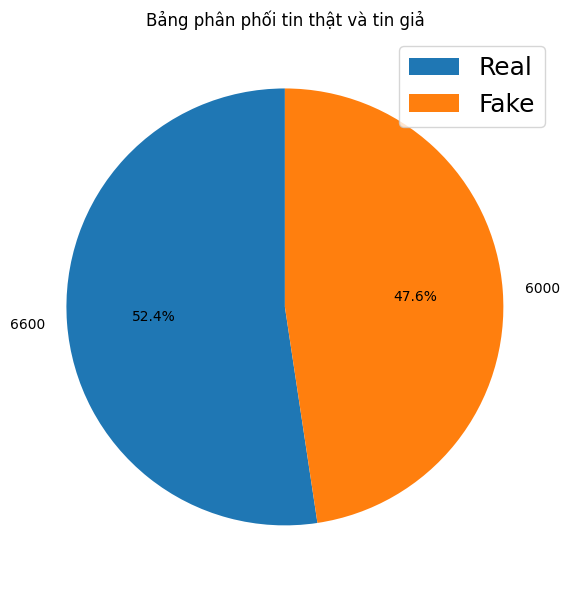

In [16]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

#### Các thông tin thống kê

##### Chiều dài trung bình mỗi record là bao nhiêu?

In [17]:
len_sum=0
for i in data_df['text']:
    len_sum+=len(i)
len_avg=len_sum/data_df['text'].count()
len_avg

4043.0450793650793

##### Record dài nhất là bao nhiêu?

In [18]:
max_len=0
for i in data_df['text']:
    if len(i)>max_len:
        max_len=len(i)
max_len

68695

##### Record ngắn nhất là bao nhiêu?

In [19]:
min_len=len(data_df['text'][0])
for i in data_df['text']:
    if len(i)<min_len:
        min_len=len(i)
min_len

300

### Tiền xử lí văn bản tiếng việt

#### Loại bỏ các đường link và các dấu câu, lowercase

In [20]:
from pyvi import ViTokenizer
from collections import Counter

In [21]:
def wordopt(text):
    text = text.lower()
    text = re.sub('https?:\/\/.*[\r\n]*', ' ', text)
    text = re.sub('[^\w\s]', ' ', text) 
    text = re.sub('\n', ' ', text)
    return text

#delete numbers
def delete_numbers(text):
    return re.sub(r'\d+', ' ', text)
#lower case
def lower(text):
    return text.lower()
#delete special characters
def remove_special_characters(text):
    ## Remove punctuations
    text = re.sub('[%s]' % re.escape("""!–"#$%&'()*+,،-./:;<=>؟?@[\]^`{|}~“”…"""), ' ', text)
    text = text.replace('؛',"", )
    text = re.sub('\s+', ' ', text)
    text =  " ".join(text.split())
    return text.strip()
#delete stop words
def remove_stopwords(text):
    # words = text.split()
    # mean_word = [word for word in words if word not in stopwords]
    # mean_text = " ".join(mean_word)
    clean_tokens = ' '.join([word for word in text.split() if word not in stopwords])
    return clean_tokens

def preprocess_nostop(text):
    text = delete_numbers(text)
    text = lower(text)
    text = remove_special_characters(text)
    return text


In [22]:
# Compound Vietnamese word
def tokenizerVN(text):
    return ViTokenizer.tokenize(text)
# Tokenizer
def tokenizer(text):
    return word_tokenize(text)
# Count token
def count_token(text):
    word = tokenizerVN(str(text))
    return len(word.split())
# Word Cloud
def top_count(dt):
    top = Counter([item for sublist in data_df[dt].apply(lambda x:str(x).split()) for item in sublist])
    temp = pd.DataFrame(top.most_common(50))
    temp.columns = ['Common_words','count']
    temp.style.background_gradient(cmap='Blues')
    return temp

In [23]:
data_df['article'] = ' |title| '+ data_df["title"] +' |text| '+  data_df["text"] 

In [24]:
data_df.head(1)

,title,text,label,article
0,Đồng Nai chốt thời gian bàn giao mặt bằng cao tốc Biên Hòa - Vũng Tàu,Hôm nay (25/9) ông Võ Tấn Đức - Chủ tịch UBND tỉnh Đồng Nai - cho biết địa phương cam kết đến ngày 15/10 tới toàn bộ diện tích đất của dự án sẽ cơ bản được bàn giao cho đơn vị thi công. . Để đảm bảo tiến độ ông Đức đề nghị các đơn vị thi công cao tốc Biên Hòa - Vũng Tàu tăng cường nhân lực máy móc thi công 3 ca 4 kíp để bù lại tiến độ bị trễ. . Theo báo cáo huyện Long Thành đã cơ bản hoàn thành giải phóng mặt bằng tạo điều kiện cho việc thi công được xuyên suốt. . Tại TP Biên Hòa mặc dù gặp một số khó khăn nhưng công tác giải phóng mặt bằng cũng đang được đẩy nhanh đến nay đạt khoảng 50%. Dự kiến đầu tháng 10 tới thành phố sẽ bàn giao trên 85% diện tích đất đã phê duyệt. . Cao tốc Biên Hòa - Vũng Tàu dài 53 7km được chia thành 3 dự án thành phần với tổng mức đầu tư 17.828 tỷ đồng. Đây là một trong những dự án trọng điểm của khu vực Đông Nam Bộ nhằm kết nối giao thông giữa Đồng Nai và Bà Rịa - Vũng Tàu. . Đồng Nai đảm nhận 2 dự án thành phần với tổng chiều dài 34 2km dự án thành phần 3 thuộc địa bàn tỉnh Bà Rịa - Vũng Tàu.,0,|title| Đồng Nai chốt thời gian bàn giao mặt bằng cao tốc Biên Hòa - Vũng Tàu |text| Hôm nay (25/9) ông Võ Tấn Đức - Chủ tịch UBND tỉnh Đồng Nai - cho biết địa phương cam kết đến ngày 15/10 tới toàn bộ diện tích đất của dự án sẽ cơ bản được bàn giao cho đơn vị thi công. . Để đảm bảo tiến độ ông Đức đề nghị các đơn vị thi công cao tốc Biên Hòa - Vũng Tàu tăng cường nhân lực máy móc thi công 3 ca 4 kíp để bù lại tiến độ bị trễ. . Theo báo cáo huyện Long Thành đã cơ bản hoàn thành giải phóng mặt bằng tạo điều kiện cho việc thi công được xuyên suốt. . Tại TP Biên Hòa mặc dù gặp một số khó khăn nhưng công tác giải phóng mặt bằng cũng đang được đẩy nhanh đến nay đạt khoảng 50%. Dự kiến đầu tháng 10 tới thành phố sẽ bàn giao trên 85% diện tích đất đã phê duyệt. . Cao tốc Biên Hòa - Vũng Tàu dài 53 7km được chia thành 3 dự án thành phần với tổng mức đầu tư 17.828 tỷ đồng. Đây là một trong những dự án trọng điểm của khu vực Đông Nam Bộ nhằm kết nối giao thông giữa Đồng Nai và Bà Rịa - Vũng Tàu. . Đồng Nai đảm nhận 2 dự án thành phần với tổng chiều dài 34 2km dự án thành phần 3 thuộc địa bàn tỉnh Bà Rịa - Vũng Tàu.


In [25]:
data_df['Compound_Content'] = data_df['article'].apply(tokenizerVN)
data_df['Compound_Content_SW'] = data_df['Compound_Content'].apply(preprocess_nostop)

In [26]:
data_df['Compound_Content_SW'][1]

'title thủ_tướng chuyển_đổi số đã đến từng ngõ từng nhà và từng người text theo cổng thông_tin điện_tử chính_phủ sáng tại đà_nẵng thủ_tướng phạm_minh chính chủ_tịch ủy_ban quốc_gia về chuyển_đổi số chủ_trì hội_nghị trực_tuyến toàn_quốc chuyên_đề nâng cao hiệu_quả cung_cấp và sử_dụng dịch_vụ công trực_tuyến với mục_tiêu đưa việc triển_khai dịch_vụ công trực_tuyến sang giai_đoạn mới phát_triển theo chiều sâu hội_nghị được kết_nối trực_tuyến từ điểm cầu chính tại trung_tâm hành_chính công đà_nẵng tới ubnd các tỉnh_thành_phố trực_thuộc trung_ương quang_cảnh của hội_nghị tại đà_nẵng ảnh a_núi phát_biểu khai_mạc thủ_tướng phạm_minh chính nêu rõ đang rà_soát lại việc thực_hiện các mục_tiêu nhiệm_vụ theo nghị_quyết đại_hội xiii của đảng những việc đã làm tốt rồi thì làm tốt hơn những mục_tiêu có khả_năng đạt được cần tăng_tốc những gì chưa đạt được phải có giải_pháp đột_phá mặt_khác đà_nẵng là một trong những địa_phương đi đầu trong xây_dựng chính_phủ số đạt hiệu_quả nổi_trội việc tổ_chức hội_

# **Visualization**

Visualize Functions

In [27]:
# word cloud

In [28]:
# from wordcloud import WordCloud
# import seaborn as sns

In [29]:
# # Top common words column
# def top_count_column(dt):
#     top = Counter([item for sublist in data_df[dt].apply(lambda x: str(x).split()) for item in sublist])
#     temp = pd.DataFrame(top.most_common(20))
#     temp.columns = ['Common_words', 'count']

#     # Visualization
#     plt.figure(figsize=(12, 8))
#     plt.barh(temp['Common_words'][::-1], temp['count'][::-1], color='skyblue')
#     plt.xlabel('Count')
#     plt.ylabel('Common Words')
#     plt.title('Top 20 Common Words')
#     plt.show()


# #Count word
# word_count_SW = data_df['Compound_Content_SW'].apply(count_token)


# # Plot data distribution
# def seaborn_token(word_count):
#     data_df['Word_count_SW'] = word_count
#     sns.stripplot(y='Word_count_SW', data = data_df , jitter=True)

#     plt.ylabel('Quantity Token')
#     plt.xlabel('Seaborn Strip Plot Count without stop words')

# def word_count():
#     plt.figure(figsize=(20, 7))  # Chỉ cần tạo một hình lớn

#     plt.hist(data_df["Word_count_SW"], bins=50)  # Vẽ biểu đồ histogram cho dữ liệu

#     plt.title('Word count have stop words')  # Đặt tiêu đề cho biểu đồ

#     plt.xlabel('Number of Words')  # Nhãn cho trục x (tùy chọn)
#     plt.ylabel('Frequency')  # Nhãn cho trục y (tùy chọn)

#     plt.show()  # Hiển thị biểu đồ


# def word_cloud(df):
#     plt.subplots(figsize=(20, 10))

#     wordcloud = WordCloud (
#                         background_color = 'white',
#                         width = 512,
#                         height = 384
#                             ).generate(' '.join(df))
#     plt.imshow(wordcloud) # image show
#     plt.axis('off') # to off the axis of x and y
#     # plt.savefig('Plotly_World_Cloud.png')
#     plt.show()

In [30]:
# data_df.head(1)

In [31]:
# top_count = top_count("Compound_Content_SW")
# top_count.style.background_gradient(cmap='Blues')

In [32]:
# top_count_column('Compound_Content_SW')

In [33]:
# seaborn_token(word_count_SW)

In [34]:
# word_count()

Word Cloud

In [35]:
# word_cloud(top_count['Common_words'])

In [36]:
#END

#### Tokenizer

In [37]:
# from pyvi import ViTokenizer
# def tokenize(sentence):
#     return word_tokenize(sentence, format = 'word')
#     # return ViTokenizer.tokenize(sentence).split()  # Tokenize và tách thành danh sách từ
def tokenize(sentence):
    return tokenizerVN(sentence).split()


### Mô hình hóa

- Chuyển đoạn văn tiếng Việt về vector, sử dụng CountVectorizer của sklearn
- với các tham số là danh sách stopwords tiếng Việt
- và tokenizer tách từ tiếng Việt

In [38]:
from sklearn.feature_extraction.text import CountVectorizer

In [39]:
vectorizer = CountVectorizer(
    stop_words = stopwords,
    tokenizer = tokenize,
)

In [40]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

In [41]:
X = data_df['Compound_Content_SW']
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)
Xv_train = vectorizer.fit_transform(X_train)
Xv_test = vectorizer.transform(X_test)

In [44]:
joblib.dump(vectorizer, model_vector)

['../../Model/Vietnamese\\vectorizer.joblib']

In [45]:
DT = DecisionTreeClassifier()
DT.fit(Xv_train,y_train)

DecisionTreeClassifier()

In [46]:
pred_dt = DT.predict(Xv_test)
print(DT.score(Xv_test, y_test))
#save model Decision Tree
joblib.dump(DT, model_DTC)

0.9187301587301587


['../../Model/Vietnamese\\DT_model.joblib']

In [47]:
NB = MultinomialNB()
NB.fit(Xv_train,y_train)

MultinomialNB()

In [48]:
pred_nb = DT.predict(Xv_test)
print(NB.score(Xv_test, y_test))
#save model Naive Bayes
joblib.dump(NB, model_NB)

0.9514285714285714


['../../Model/Vietnamese\\NB_model.joblib']